X shape: (200, 2)  | y shape: (200,)  | m = 200


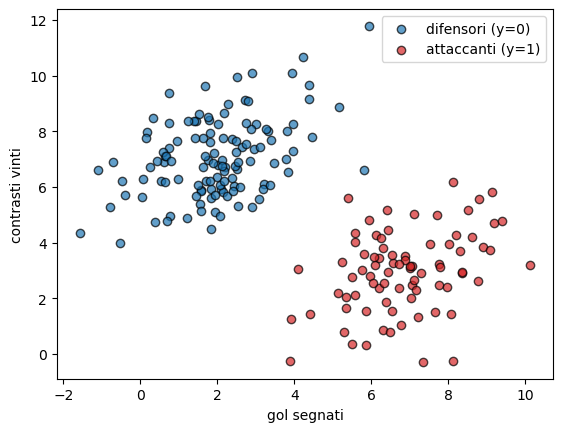

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(6)

# Scenario: classifichiamo un calciatore -> DIFENSORE (y=0) vs ATTACCANTE (y=1)
# 2 feature:  x = [gol_segnati, contrasti_vinti]
#
# Generiamo i dati ESATTAMENTE come li immagina il modello GDA:
#   ogni classe e' una campana gaussiana, con la STESSA forma (Sigma condivisa)
#   ma centro diverso (mu0 per i difensori, mu1 per gli attaccanti).
mu0_vero = np.array([2.0, 7.0])           # difensori: pochi gol, tanti contrasti
mu1_vero = np.array([7.0, 3.0])           # attaccanti: tanti gol, pochi contrasti
Sigma_vero = np.array([[2.0, 0.8],
                       [0.8, 2.0]])       # forma CONDIVISA dalle due classi

m0, m1 = 120, 80                          # 120 difensori, 80 attaccanti (classi sbilanciate -> phi != 0.5)
X0 = np.random.multivariate_normal(mu0_vero, Sigma_vero, m0)
X1 = np.random.multivariate_normal(mu1_vero, Sigma_vero, m1)
X = np.vstack([X0, X1])                    # (200, 2)
y = np.array([0]*m0 + [1]*m1)             # etichette: 0 = difensore, 1 = attaccante
m = X.shape[0]

print("X shape:", X.shape, " | y shape:", y.shape, " | m =", m)

plt.scatter(X[y==0,0], X[y==0,1], color='#1f77b4', edgecolors='k', alpha=0.7, label='difensori (y=0)')
plt.scatter(X[y==1,0], X[y==1,1], color='#d62728', edgecolors='k', alpha=0.7, label='attaccanti (y=1)')
plt.xlabel("gol segnati"); plt.ylabel("contrasti vinti"); plt.legend(); plt.show()

In [2]:
# STIMA DEI PARAMETRI (formule chiuse della MLE — niente iterazioni, niente alpha)

# phi = frazione di esempi con y=1  ("quanti attaccanti su m giocatori?")
phi = np.mean(y == 1)

# mu0 = media delle x dei SOLI difensori ; mu1 = media delle x dei SOLI attaccanti
mu0 = X[y == 0].mean(axis=0)        # (2,)  baricentro dei difensori
mu1 = X[y == 1].mean(axis=0)        # (2,)  baricentro degli attaccanti

# Sigma CONDIVISA: ogni punto si scosta dal centro DELLA SUA classe, poi mediamo
mu_di_ciascuno = np.where(y[:, None] == 1, mu1, mu0)   # (200, 2): a ogni riga il "suo" centro
diff = X - mu_di_ciascuno                              # (200, 2): scostamenti dal proprio centro
Sigma = (diff.T @ diff) / m                            # (2, 2): media dei prodotti esterni

print("phi   =", round(float(phi), 3))
print("mu0   =", mu0.round(3), "  (vero:", mu0_vero, ")")
print("mu1   =", mu1.round(3), "  (vero:", mu1_vero, ")")
print("Sigma =\n", Sigma.round(3))

phi   = 0.4
mu0   = [1.983 7.051]   (vero: [2. 7.] )
mu1   = [6.842 2.962]   (vero: [7. 3.] )
Sigma =
 [[1.776 0.75 ]
 [0.75  2.031]]


In [3]:
from numpy.linalg import inv, det

Sigma_inv = inv(Sigma)
norm = 1.0 / np.sqrt((2*np.pi)**2 * det(Sigma))   # costante davanti alla gaussiana (n=2 feature)

# p(x | classe centrata in mu): densità gaussiana multivariata, valutata riga per riga
def p_x_dato_classe(X, mu):
  d = X - mu                                     # scostamento dal centro
  quad = np.sum((d @ Sigma_inv) * d, axis=1)     # (x-mu)^T Σ^-1 (x-mu) per ogni riga
  return norm * np.exp(-0.5 * quad)

# Predizione: confronto  p(x|y=1)·phi   vs   p(x|y=0)·(1-phi)
def predici(X):
  post1 = p_x_dato_classe(X, mu1) * phi          # numeratore di Bayes, classe 1
  post0 = p_x_dato_classe(X, mu0) * (1 - phi)    # numeratore di Bayes, classe 0
  return (post1 > post0).astype(int)

# Accuracy sul training
pred = predici(X)
print("accuracy:", round(float((pred == y).mean()*100), 1), "%")

# Giocatore nuovo: 6 gol, 3 contrasti
nuovo = np.array([[6.0, 3.0]])
print("nuovo [6 gol, 3 contrasti] -> classe", int(predici(nuovo)[0]))

accuracy: 100.0 %
nuovo [6 gol, 3 contrasti] -> classe 1


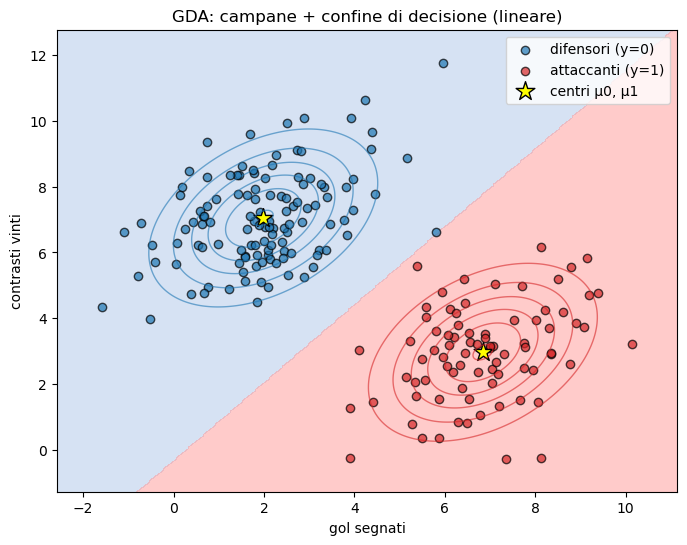

In [4]:
# Griglia che copre il piano
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                   np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
griglia = np.c_[xx.ravel(), yy.ravel()]          # (90000, 2)

plt.figure(figsize=(8, 6))

# 1) REGIONI DI DECISIONE: coloro il piano in base alla classe vincente
zone = predici(griglia).reshape(xx.shape)
plt.contourf(xx, yy, zone, levels=[-0.5, 0.5, 1.5],
           colors=['#aec7e8', '#ff9896'], alpha=0.5)

# 2) LE DUE CAMPANE: curve di livello della densità di ciascuna classe
dens0 = p_x_dato_classe(griglia, mu0).reshape(xx.shape)
dens1 = p_x_dato_classe(griglia, mu1).reshape(xx.shape)
plt.contour(xx, yy, dens0, colors='#1f77b4', alpha=0.6, linewidths=1)
plt.contour(xx, yy, dens1, colors='#d62728', alpha=0.6, linewidths=1)

# 3) i punti e i centri stimati
plt.scatter(X[y==0,0], X[y==0,1], color='#1f77b4', edgecolors='k', alpha=0.7, label='difensori (y=0)')
plt.scatter(X[y==1,0], X[y==1,1], color='#d62728', edgecolors='k', alpha=0.7, label='attaccanti (y=1)')
plt.scatter([mu0[0], mu1[0]], [mu0[1], mu1[1]], color='yellow', edgecolors='k',
          s=200, marker='*', label='centri μ0, μ1')

plt.xlabel("gol segnati"); plt.ylabel("contrasti vinti")
plt.title("GDA: campane + confine di decisione (lineare)")
plt.legend(); plt.show()